# Healthcare Trends in the United States (2004 – Present)

## Consumer Price Index (CPI) & Health Care Producer Index Year-over-Year

### Description

This notebook provides a technical visualization of U.S. healthcare inflationary trends over the past two decades. Utilizing data retrieved from the Federal Reserve Economic Data (FRED) system, it evaluates and contrasts key consumer and producer price metrics:

- **Medical Care CPI (All Urban Consumers | FRED: CPIMEDSL):** Reflects the year-over-year price changes for medical care services and commodities paid for by the ultimate consumer.
- **Healthcare Services PPI (By Commodity | FRED: WPU51):** Tracks the average structural price changes received by domestic producers for providing healthcare services.

The analysis is conducted using year-over-year (YoY) percentage changes, allowing for a smoothed structural overview of consumer healthcare costs and underlying producer price momentum.

---

## Objectives

- **Long-Term Trend Analysis:** Evaluate structural healthcare inflation patterns from 2004 through the present day.
- **Metric Variance:** Compare the sensitivity and decoupling behavior of consumer-facing medical indices versus provider-facing producer price indices during macroeconomic shocks.
- **Macroeconomic Chronology:** Identify and map specific historical periods of structural inflation acceleration (reflation) and deceleration (disinflation/deflation) within the healthcare sector.
- **Policy Contextualization:** Provide a data-driven timeline mapping healthcare price fluctuations to Federal Reserve monetary cycles and global economic events.

---

## Data Source

- **Federal Reserve Economic Data (FRED)**  
  - `CPIMEDSL`: Consumer Price Index for All Urban Consumers: Medical Care in U.S. City Average
  - `WPU51`: Producer Price Index by Commodity: Health Care Services
  - `CUSR0000SAM1`: Consumer Price Index for All Urban Consumers: Medical Care Commodities in U.S. City Average 
  - `DHLCRC1Q027SBEA`: Personal consumption expenditures: Services: Health care
  - `CPIEMEDCARE`: Research Consumer Price Index: Medical Care

---

## CPI Inflation (2004–Present): Historical Chronology

### Major Macroeconomic Events Impacting Trends:
- **2008 Great Recession & Housing Market Collapse:** Sharp contraction in aggregate demand leading to historical disinflationary/deflationary pressures.
- **2020 COVID-19 Pandemic:** Initial deflationary shock followed by massive global supply-chain disruptions and unprecedented fiscal stimulus.
- **2021–2023 Post-Pandemic Inflationary Surge:** A historic peak in global inflation driven by surging consumer demand, structural labor shortages, and energy market imbalances.
- **2022–2024 Fed Monetary Tightening Cycle:** Aggressive interest rate hikes enacted by the Federal Reserve to cool demand and anchor long-term inflation expectations back to the 2.0% target.
- **Global Geopolitical Friction (2022–Present):** Supply chain friction and commodity shocks amplified by the Russia-Ukraine war and escalating conflicts in the Middle East.

## Pre-Processing

### Install System Dependencies

In [2]:
!pip install pandas-datareader
# Note: Uncomment below if necessary to ugrade installer
# !pip3 install --upgrade pip

### Import Python Libraries

In [3]:
import pandas as pd
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

### Define Global Functions 

In [4]:
def add_event_lines(events, df_plot, y_position):
    """
    Plots vertical lines and labels for specific events within the date range of df_plot.
    
    Parameters:
    - events (dict): A dictionary of {'date_string': 'label'}.
    - df_plot (DataFrame): The pandas DataFrame being plotted (expects a DatetimeIndex).
    - y_position (float): The y-axis coordinate for the text labels.
    """
    for date_str, label in events.items():
        evt_date = pd.to_datetime(date_str)
        
        if df_plot.index.min() <= evt_date <= df_plot.index.max():
            plt.axvline(x=evt_date, 
                        color='black', 
                        linestyle=':', 
                        linewidth=1.2, 
                        alpha=0.7)
            
            plt.text(evt_date, y_position, label,
                     rotation=90, 
                     verticalalignment='top',
                     horizontalalignment='right',
                     fontsize=10,
                     fontweight='bold')
            
def add_event_lines_small(events, df_plot, y_position):
    """
    Plots vertical lines and labels for specific events within the date range of df_plot.
    
    Parameters:
    - events (dict): A dictionary of {'date_string': 'label'}.
    - df_plot (DataFrame): The pandas DataFrame being plotted (expects a DatetimeIndex).
    - y_position (float): The y-axis coordinate for the text labels.
    """
    for date_str, label in events.items():
        evt_date = pd.to_datetime(date_str)
        
        if df_plot.index.min() <= evt_date <= df_plot.index.max():
            plt.axvline(x=evt_date, 
                        color='black', 
                        linestyle=':', 
                        linewidth=1.2, 
                        alpha=0.7)
            
            plt.text(evt_date, y_position, label,
                     rotation=90, 
                     verticalalignment='top',
                     horizontalalignment='right',
                     fontsize=5,
                     fontweight='bold')

### Standard Unit Initial Timeframe

In [5]:
start = datetime(2005, 1, 1)
end = datetime.now()
str_current_date = end.strftime("%B %d, %Y")
plot_start = start + relativedelta(years=1)

## Medical Care Services and Commodities  Inflation: 20-Year Historical

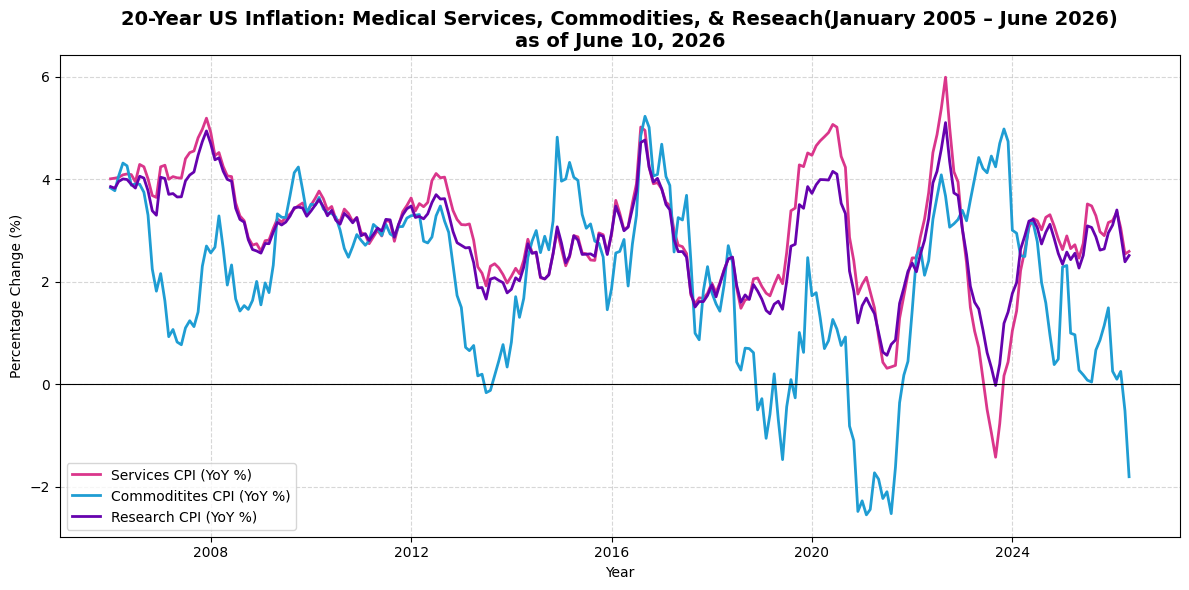

In [6]:
mcpi_series = {
'CPIMEDSL': 'Medical Care CPI in U.S. City Average', 
'CUSR0000SAM1': 'Medical Care Commodities CPI in U.S. City Average',
'CPIEMEDCARE': 'Research CPI - Over 62 y/o'
}

df = web.DataReader(list(mcpi_series.keys()), 'fred', start, end)
df.rename(columns=mcpi_series, inplace=True)
df = df.ffill()

df_yoy = df.pct_change(periods=12) * 100

plt.figure(figsize=(12, 6))

plt.plot(df_yoy.index, 
        df_yoy['Medical Care CPI in U.S. City Average'],
        label='Services CPI (YoY %)', 
        color="#da368b", 
        linewidth=2)

plt.plot(df_yoy.index, 
        df_yoy['Medical Care Commodities CPI in U.S. City Average'],
        label='Commoditites CPI (YoY %)', 
        color="#1f9dd3", 
        linewidth=2)

plt.plot(df_yoy.index, 
        df_yoy['Research CPI - Over 62 y/o'],
        label='Research CPI (YoY %)', 
        color="#6602ae", 
        linewidth=2)

y = plt.ylim()[1]*0.85

# plot formatting
plt.title(f'20-Year US Inflation: Medical Services, Commodities, & Reseach({start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Percentage Change (%)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

plt.show()

## 10-Year Historical Index

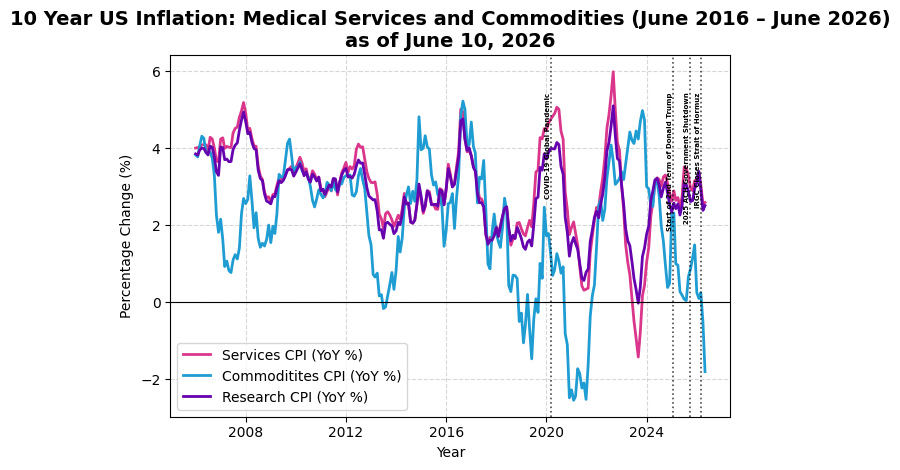

In [11]:
# timeframe
start = datetime(2016, 6, 1)

plt.plot(df_yoy.index, 
        df_yoy['Medical Care CPI in U.S. City Average'],
        label='Services CPI (YoY %)', 
        color="#da368b", 
        linewidth=2)

plt.plot(df_yoy.index, 
        df_yoy['Medical Care Commodities CPI in U.S. City Average'],
        label='Commoditites CPI (YoY %)', 
        color="#1f9dd3", 
        linewidth=2)

plt.plot(df_yoy.index, 
        df_yoy['Research CPI - Over 62 y/o'],
        label='Research CPI (YoY %)', 
        color="#6602ae", 
        linewidth=2)

y = plt.ylim()[1]*0.85

events = {
'2007-12-01': '2008 U.S. Housing Crisis Recession',
'2020-03-01': 'COVID-19 Global Pandemic',
'2025-01-20': 'Start of 2nd Term of Donald Trump',
'2025-10-01': '2025 ACH Government Shutdown',
'2026-02-28': 'IRGC Closes Strait of Hormuz'
}

# plot formatting
plt.title(f'10 Year US Inflation: Medical Services and Commodities ({start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Percentage Change (%)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
add_event_lines_small(events , df, y)
plt.legend()
plt.tight_layout()

plt.show()

## CPI Inflation (June 2024-Present)
### Key Events
- Presidential Inauguration of Donald J. Trump's as the 47th President of the United States of America.
- Effective start of President Trump's global tariffs policy.
- U.S. Congressional 43-day shutdown.
- Iran closed the Straight of Hormuz.

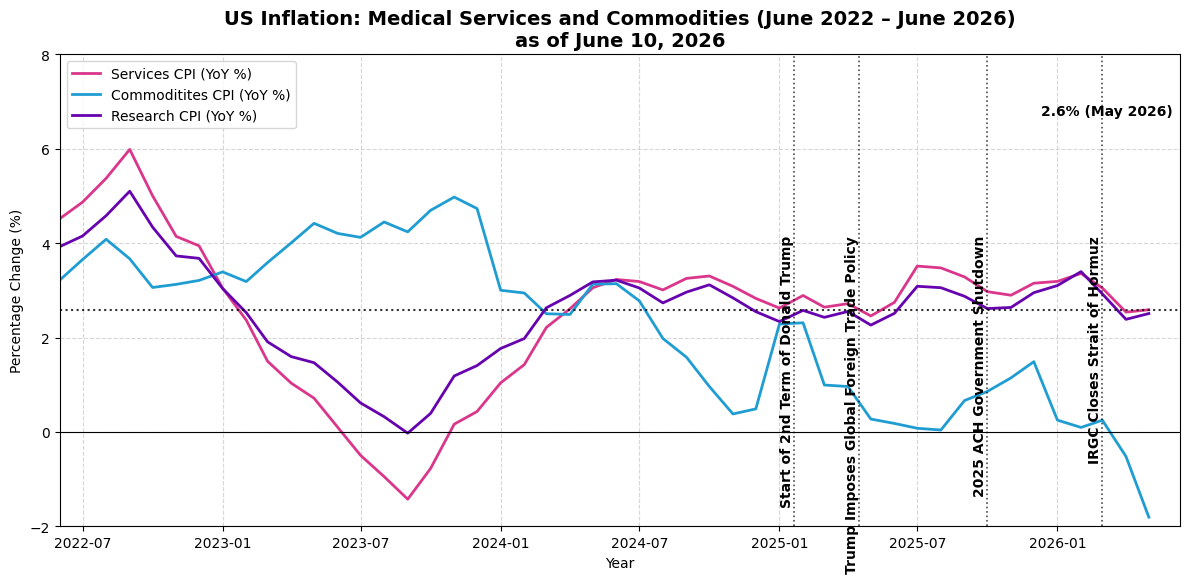

In [13]:
events = {
'2025-01-20': 'Start of 2nd Term of Donald Trump',
'2025-4-15': 'Trump Imposes Global Foreign Trade Policy',
'2025-10-01': '2025 ACH Government Shutdown',
'2026-02-28': 'IRGC Closes Strait of Hormuz'
}

# values
r_date = df_yoy['Medical Care CPI in U.S. City Average'].dropna().index[-1]
r_val = df_yoy['Medical Care CPI in U.S. City Average'].dropna().iloc[-1]

# timeframe
start = datetime(2022, 6, 1)

# Plot
plt.figure(figsize=(12, 6))

plt.plot(df_yoy.index, 
        df_yoy['Medical Care CPI in U.S. City Average'],
        label='Services CPI (YoY %)', 
        color="#da368b", 
        linewidth=2)

plt.plot(df_yoy.index, 
        df_yoy['Medical Care Commodities CPI in U.S. City Average'],
        label='Commoditites CPI (YoY %)', 
        color="#1f9dd3", 
        linewidth=2)

plt.plot(df_yoy.index, 
        df_yoy['Research CPI - Over 62 y/o'],
        label='Research CPI (YoY %)', 
        color="#6602ae", 
        linewidth=2)

y = plt.ylim()[1]*0.65

# Formatting
plt.title(f'US Inflation: Medical Services and Commodities ({start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Percentage Change (%)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.xlim(start, end)
plt.ylim(-2,8)
add_event_lines(events, df, y)
plt.annotate(f"{r_val:.1f}% ({r_date.strftime('%b %Y')})", 
             (r_date, r_val), 
             textcoords = "offset points", 
             xytext = (-30,140), 
             ha = 'center', 
             weight = 'bold', 
             color = 'black')
plt.axhline(y=r_val, 
            color="#000000", 
            linestyle=':', 
            linewidth=1.5, 
            alpha=0.8)

plt.legend()
plt.tight_layout()

plt.show()

## Personal Consumption Expenditures (PCE)

### Health Care Services: 10-Year Historical 

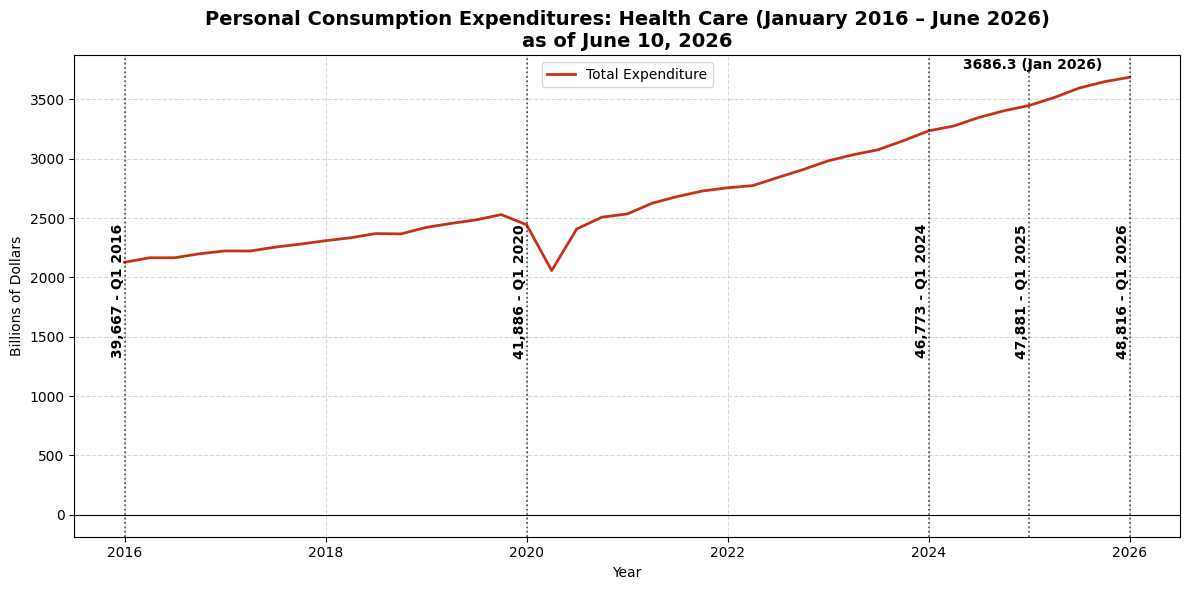

In [15]:
# source: FRED
df = web.DataReader('DHLCRC1Q027SBEA', 'fred', start, end)

# values
r_date = df['DHLCRC1Q027SBEA'].dropna().index[-1]
r_val = df['DHLCRC1Q027SBEA'].dropna().iloc[-1]

# timeframe
start = datetime(2016, 1, 1)
plot_start = start + relativedelta(years=1)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['DHLCRC1Q027SBEA'], 
         label="Total Expenditure", 
         color="#c23317", 
         linewidth=2)

y = plt.ylim()[1]*0.65

# Q1 2016-2026
fyq_s1 = {
    '2016-01-1': '39,667 - Q1 2016',
    '2020-01-1': '41,886 - Q1 2020',
    '2024-01-1': '46,773 - Q1 2024',
    '2025-01-1': '47,881 - Q1 2025',
    '2026-01-1': '48,816 - Q1 2026'
}

plt.title(f'Personal Consumption Expenditures: Health Care ({start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Billions of Dollars')
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
add_event_lines(fyq_s1, df, y)
plt.annotate(f"{r_val:.1f} ({r_date.strftime('%b %Y')})", 
             (r_date, r_val), 
             textcoords = "offset points", 
             xytext = (-70,6), 
             ha = 'center', 
             weight = 'bold', 
             color = 'black')
plt.legend()
plt.tight_layout()

plt.show()

## Producer Price Index by Commodity: Health Care Services

### Health Care Services PPI: 5-Year Historical

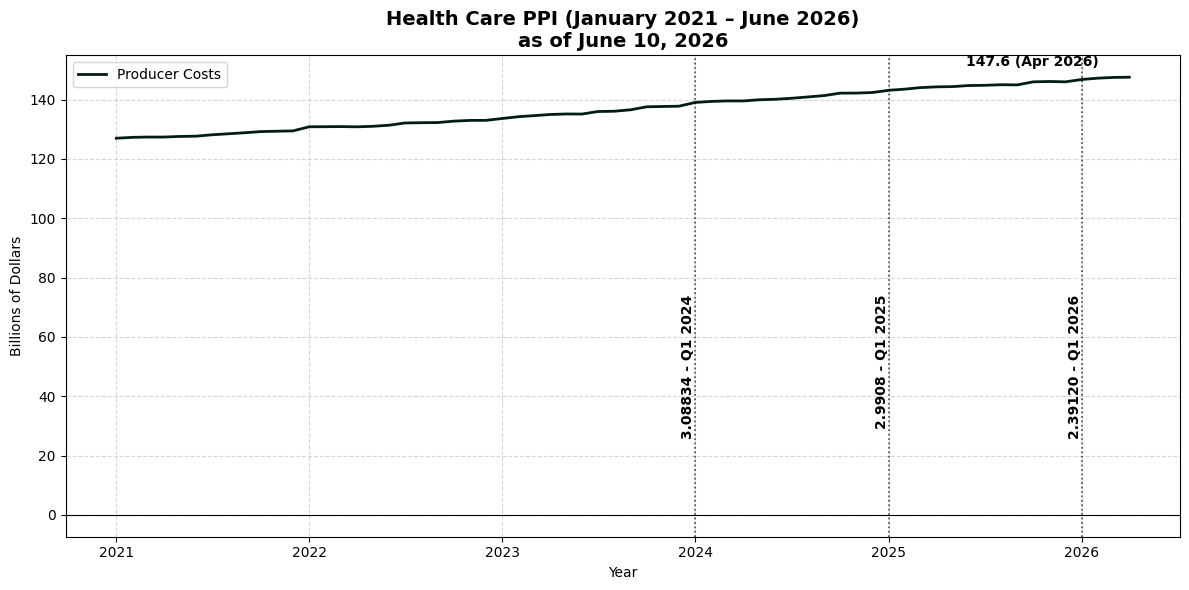

In [17]:
# source
df = web.DataReader('WPU51', 'fred', start, end)

# values
r_date = df['WPU51'].dropna().index[-1]
r_val = df['WPU51'].dropna().iloc[-1]

# timeframe
start = datetime(2021, 1, 1)
plot_start = start + relativedelta(years=1)

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['WPU51'], 
         label="Producer Costs", 
         color="#011d11", 
         linewidth=2)

y = plt.ylim()[1]*0.5

# Event Markers
fyq_s2 = {
    '2024-01-1': '3.08834 - Q1 2024',
    '2025-01-1': '2.9908 - Q1 2025',
    '2026-01-1': '2.39120 - Q1 2026'
}

plt.title(f'Health Care PPI ({start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Billions of Dollars')
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
add_event_lines(fyq_s2, df, y)
plt.annotate(f"{r_val:.1f} ({r_date.strftime('%b %Y')})", 
             (r_date, r_val), 
             textcoords = "offset points", 
             xytext = (-70,8), 
             ha = 'center', 
             weight = 'bold', 
             color = 'black')


plt.show()

# Conclusions and Observations

***In Progress***

## Update Schedule
### 1) Producer Price Index (PPI): Thursday, June 11, 2026, at 8:30 A.M. Eastern Time.

### 2) Personal Consumption Expenditures (PCE) Index: Wednesday, June 25, 2026.

### 3) Consumer Price Index (CPI) Index: Wednesday, July 14, 2026.

#### ***Review and analysis publishing on Friday, July 10, 2026, at 1:30 P.M. Pacific Time.***